### Bayes Model Selection

The notebook implement related stuffs mentioned in https://www.overleaf.com/project/6a7592f575d67477ad61c188

For this notebook, the author will choose StatLog Heart as the dataset for analyzing due to its simplicity.  

### Data Preprocessing

In [1]:
from ucimlrepo import fetch_ucirepo

statlog_heart = fetch_ucirepo(id=145)
X = statlog_heart.data.features
y = statlog_heart.data.targets 
X.describe()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


Some basic stats on the features 

In [2]:
X.head()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0


In [3]:
y.head()

,heart-disease
0,2
1,1
2,2
3,1
4,1


In [4]:
print(f"no columns: {len(X.columns)}")
print(X.columns.tolist())

no columns: 13
['age', 'sex', 'chest-pain', 'rest-bp', 'serum-chol', 'fasting-blood-sugar', 'electrocardiographic', 'max-heart-rate', 'angina', 'oldpeak', 'slope', 'major-vessels', 'thal']


Now, we will conduct data clean up with:

- Keep 8 columns for predictor
- Define binary target
- Standardize every non-intercept column

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
chosen_columns = [0, 1, 3, 4, 5, 7, 8, 9]
scaled_columns = [0, 3, 4, 7, 9]
X.iloc[:, scaled_columns] = scaler.fit_transform(
    X.iloc[:, scaled_columns]
)

chosen_X = X.iloc[: ,chosen_columns]
chosen_y = y.copy()
chosen_y["heart-disease"] = chosen_y["heart-disease"].replace(
    {
        2: 1,
        1: 0, 
    }
)

In [6]:
chosen_X.head()

,age,sex,rest-bp,serum-chol,fasting-blood-sugar,max-heart-rate,angina,oldpeak
0,1.712094,1.0,-0.075410,1.402212,0.0,-1.759208,0.0,1.181012
1,1.382140,0.0,-0.916759,6.093004,0.0,0.446409,0.0,0.481153
2,0.282294,1.0,-0.411950,0.219823,0.0,-0.375291,0.0,-0.656118
3,1.052186,1.0,-0.187590,0.258589,0.0,-1.932198,1.0,-0.743600
4,2.152032,0.0,-0.636310,0.374890,0.0,-1.240239,1.0,-0.743600


In [7]:
chosen_y

,heart-disease
0,1
1,0
2,1
3,0
4,0
...,...
265,0
266,0
267,0
268,0


Okay, now let's proceed to different stages of the main project

In [8]:
from libs import MCMC, AcceptanceTracker, SMC 

### Stage 1: Bayesian Logistic without Variable Selection

- Fit Bayesian Logistic Regression for all selected predictor
- SMC to sample from posterior
- Report Posterior Means, Credible Interval, Posterior Predictive Perf
- SMC est of Normalizing Constant.

The prior and posterior logpdf are defined as follow: 

In [9]:
from collections import namedtuple
from jax.scipy.stats import norm
from jax import numpy as jnp

LogisticRegParams = namedtuple("LogisticRegParams", ["alpha", "betas"])


def _to_named_params(params):
    """Accept LogisticRegParams or flat/(d,1) array and return LogisticRegParams."""
    if isinstance(params, LogisticRegParams):
        alpha = jnp.asarray(params.alpha).reshape(())
        betas = jnp.ravel(jnp.asarray(params.betas))
        return LogisticRegParams(alpha=alpha, betas=betas)

    flat = jnp.ravel(jnp.asarray(params))
    return LogisticRegParams(alpha=flat[0], betas=flat[1:])


def prior_log_pdf(params):
    p = _to_named_params(params)
    log_alpha = norm.logpdf(p.alpha, loc=0.0, scale=3.0)
    log_betas = jnp.sum(norm.logpdf(p.betas, loc=0.0, scale=1.5))
    return log_alpha + log_betas


def likelihood_log_pdf(params, X_observed, y_observed):
    p = _to_named_params(params)
    X_observed = jnp.atleast_2d(jnp.asarray(X_observed))
    y_observed = jnp.ravel(jnp.asarray(y_observed))

    # shape-safe linear predictor (works for 1D/2D beta inputs)
    eta = p.alpha + jnp.matmul(X_observed, p.betas[:, None]).squeeze(-1)
    return jnp.sum(y_observed * eta - jnp.logaddexp(0.0, eta))


def posterior_log_pdf(params, X_observed, y_observed):
    return prior_log_pdf(params) + likelihood_log_pdf(params, X_observed, y_observed)


Define the proposed function for next alpha and betas. 

In [10]:
import jax.numpy as jnp
from jax import random

def proposed_fn(params, key):
    """Random-walk proposal preserving LogisticRegParams format."""
    p = _to_named_params(params)
    key1, key2 = random.split(key)

    new_alpha = p.alpha + 0.1 * random.normal(key1)
    new_betas = p.betas + 0.1 * random.normal(key2, shape=p.betas.shape)
    return LogisticRegParams(alpha=new_alpha, betas=new_betas)

In [11]:
from functools import partial
import jax
import jax.numpy as jnp
from jax import random


def gen_initial_samples(no_samples: int, p: int, key):
    """SMC particle matrix: [alpha, betas...] with prior draws."""
    k1, k2 = random.split(key)
    alphas = 3.0 * random.normal(k1, shape=(no_samples, 1))
    betas = 1.5 * random.normal(k2, shape=(no_samples, p))
    return jnp.concatenate([alphas, betas], axis=1)


# Convert pandas to jax arrays
X_jax = jnp.array(chosen_X.values, dtype=float)
y_jax = jnp.array(chosen_y.values, dtype=float).ravel()
X_columns = chosen_X.columns

p = X_jax.shape[1]

def _vector_to_named(vec):
    vec = jnp.ravel(vec)
    return LogisticRegParams(alpha=vec[0], betas=vec[1:])

def _target_logpdf_single(vec, X_observed, y_observed):
    return posterior_log_pdf(_vector_to_named(vec), X_observed, y_observed)

def _prior_logpdf_single(vec):
    return prior_log_pdf(_vector_to_named(vec))

def target_logpdf_vec(vec_or_batch, X_observed, y_observed):
    arr = jnp.asarray(vec_or_batch)
    if arr.ndim == 1:
        return _target_logpdf_single(arr, X_observed, y_observed)
    return jax.vmap(lambda row: _target_logpdf_single(row, X_observed, y_observed))(arr)

def prior_logpdf_vec(vec_or_batch):
    arr = jnp.asarray(vec_or_batch)
    if arr.ndim == 1:
        return _prior_logpdf_single(arr)
    return jax.vmap(_prior_logpdf_single)(arr)

def proposed_fn_vec(vec, key):
    out = proposed_fn(_vector_to_named(vec), key)
    return jnp.concatenate([jnp.array([out.alpha]), jnp.ravel(out.betas)])

### Train/Test Posterior Predictive Check

Paper Sec 8.2: split data randomly, estimate evidence on the **training** set, then compute posterior predictive probabilities on the **held-out test** set.

In [12]:
import numpy as np
from functools import partial
from jax import random
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)


def split_train_test(X, y, train_frac=0.8, seed=0):
    """Randomly split arrays into train (80%) and test (20%)."""
    X = np.asarray(X)
    y = np.ravel(np.asarray(y))
    n = X.shape[0]
    if y.shape[0] != n:
        raise ValueError(f"X and y length mismatch: {n} vs {y.shape[0]}")

    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_train = int(np.floor(train_frac * n))
    train_idx, test_idx = idx[:n_train], idx[n_train:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def posterior_predictive_probs(particles, X):
    """Monte Carlo posterior predictive P(y=1 | x, train data).

    particles: (S, 1+p) with column 0 = alpha, rest = betas
    X: (n, p)
    returns p_hat of shape (n,)
    """
    particles = np.asarray(particles)
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    alpha = particles[:, 0]
    betas = particles[:, 1:]
    if betas.shape[1] == 0:
        logits = np.broadcast_to(alpha[:, None], (alpha.shape[0], X.shape[0])).copy()
    else:
        logits = alpha[:, None] + betas @ X.T
    probs = 1.0 / (1.0 + np.exp(-np.clip(logits, -50.0, 50.0)))
    return probs.mean(axis=0)


def eval_posterior_predictive(particles, X, y):
    """Return test metrics from posterior predictive probabilities."""
    p_hat = posterior_predictive_probs(particles, X)
    y = np.ravel(np.asarray(y))
    y_hat = (p_hat >= 0.5).astype(int)
    try:
        auc = float(roc_auc_score(y, p_hat))
    except ValueError:
        auc = np.nan
    return {
        "p_hat": p_hat,
        "accuracy": float(accuracy_score(y, y_hat)),
        "roc_auc": auc,
        "brier": float(brier_score_loss(y, p_hat)),
        "log_loss": float(log_loss(y, np.clip(p_hat, 1e-15, 1 - 1e-15))),
        "log_score": float(np.sum(y * np.log(np.clip(p_hat, 1e-15, 1 - 1e-15)) + (1 - y) * np.log(np.clip(1 - p_hat, 1e-15, 1 - 1e-15)))),
    }


def run_smc_on_data(X_obs, y_obs, no_samples=10_000, seed=42):
    """SMC helpers to estimate log evidence on (X_obs, y_obs)."""
    X_obs = jnp.asarray(X_obs, dtype=float)
    y_obs = jnp.ravel(jnp.asarray(y_obs, dtype=float))
    p_obs = int(X_obs.shape[1])

    k_init, k_smc = random.split(random.key(seed))
    smc_run = SMC(
        dims=1 + p_obs,
        target_dist_logpdf=partial(target_logpdf_vec, X_observed=X_obs, y_observed=y_obs),
        prior_dist_logpdf=prior_logpdf_vec,
        proposed_fn=proposed_fn_vec,
        key=k_smc,
    )
    smc_run.reset(samples=gen_initial_samples(no_samples, p_obs, k_init))
    lam_path, log_z = smc_run.build_intermediate_dists()
    particles = np.array(smc_run.get_current_sample_list())
    return {
        "smc": smc_run,
        "particles": particles,
        "log_evidence": float(log_z),
        "lambda_path": lam_path,
    }


# 80/20 split
X_train, X_test, y_train, y_test = split_train_test(X_jax, y_jax, train_frac=0.8, seed=0)
print(f"train n={len(y_train)} ({len(y_train)/len(y_jax):.0%}), test n={len(y_test)} ({len(y_test)/len(y_jax):.0%})")

# Evidence on TRAIN
train_smc = run_smc_on_data(X_train, y_train, no_samples=10_000, seed=42)
print(f"Train SMC log evidence log p(y_train): {train_smc['log_evidence']:.6f}")
print(f"Train lambda steps: {len(train_smc['lambda_path'])}")

# Posterior predictive probabilities on TEST
stage1_test = eval_posterior_predictive(train_smc["particles"], X_test, y_test)
print("\nTest posterior predictive summary")
print(f"p_hat range: [{stage1_test['p_hat'].min():.4f}, {stage1_test['p_hat'].max():.4f}]")
print(f"accuracy : {stage1_test['accuracy']:.4f}")
print(f"ROC-AUC  : {stage1_test['roc_auc']:.4f}")
print(f"Brier    : {stage1_test['brier']:.4f}")
print(f"log loss : {stage1_test['log_loss']:.4f}")


train n=216 (80%), test n=54 (20%)
Train SMC log evidence log p(y_train): -117.305771
Train lambda steps: 16

Test posterior predictive summary
p_hat range: [0.0248, 0.9906]
accuracy : 0.7778
ROC-AUC  : 0.8708
Brier    : 0.1490
log loss : 0.4532


As report, the log evidence est is $-117.305771$. Now, let's do some Trace Plot and Histogram Plot for seeing if our trace data looks good. 

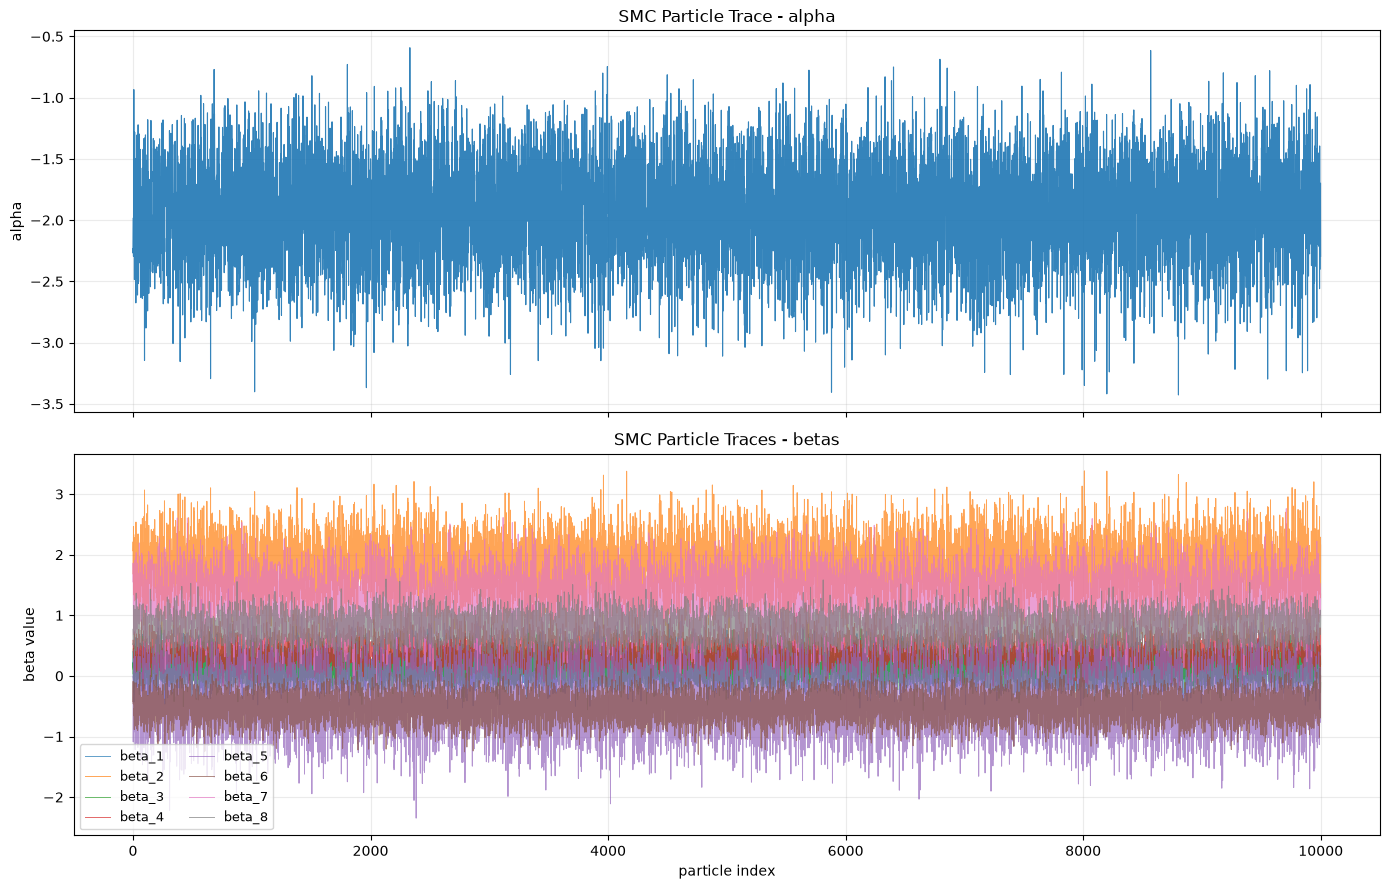

particles shape: (10000, 9)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_smc_traces(particles, max_beta_legend=10, figsize=(14, 9)):
    """Plot particle-index traces for alpha and betas."""
    alpha_trace = particles[:, 0]
    betas_trace = particles[:, 1:]

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    axes[0].plot(alpha_trace, lw=0.8, alpha=0.9)
    axes[0].set_title("SMC Particle Trace - alpha")
    axes[0].set_ylabel("alpha")
    axes[0].grid(alpha=0.25)

    for j in range(betas_trace.shape[1]):
        axes[1].plot(betas_trace[:, j], lw=0.7, alpha=0.7, label=f"beta_{j+1}")

    axes[1].set_title("SMC Particle Traces - betas")
    axes[1].set_xlabel("particle index")
    axes[1].set_ylabel("beta value")
    axes[1].grid(alpha=0.25)

    if betas_trace.shape[1] <= max_beta_legend:
        axes[1].legend(loc="best", ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"particles shape: {particles.shape}")


# Usage
plot_smc_traces(train_smc["particles"])

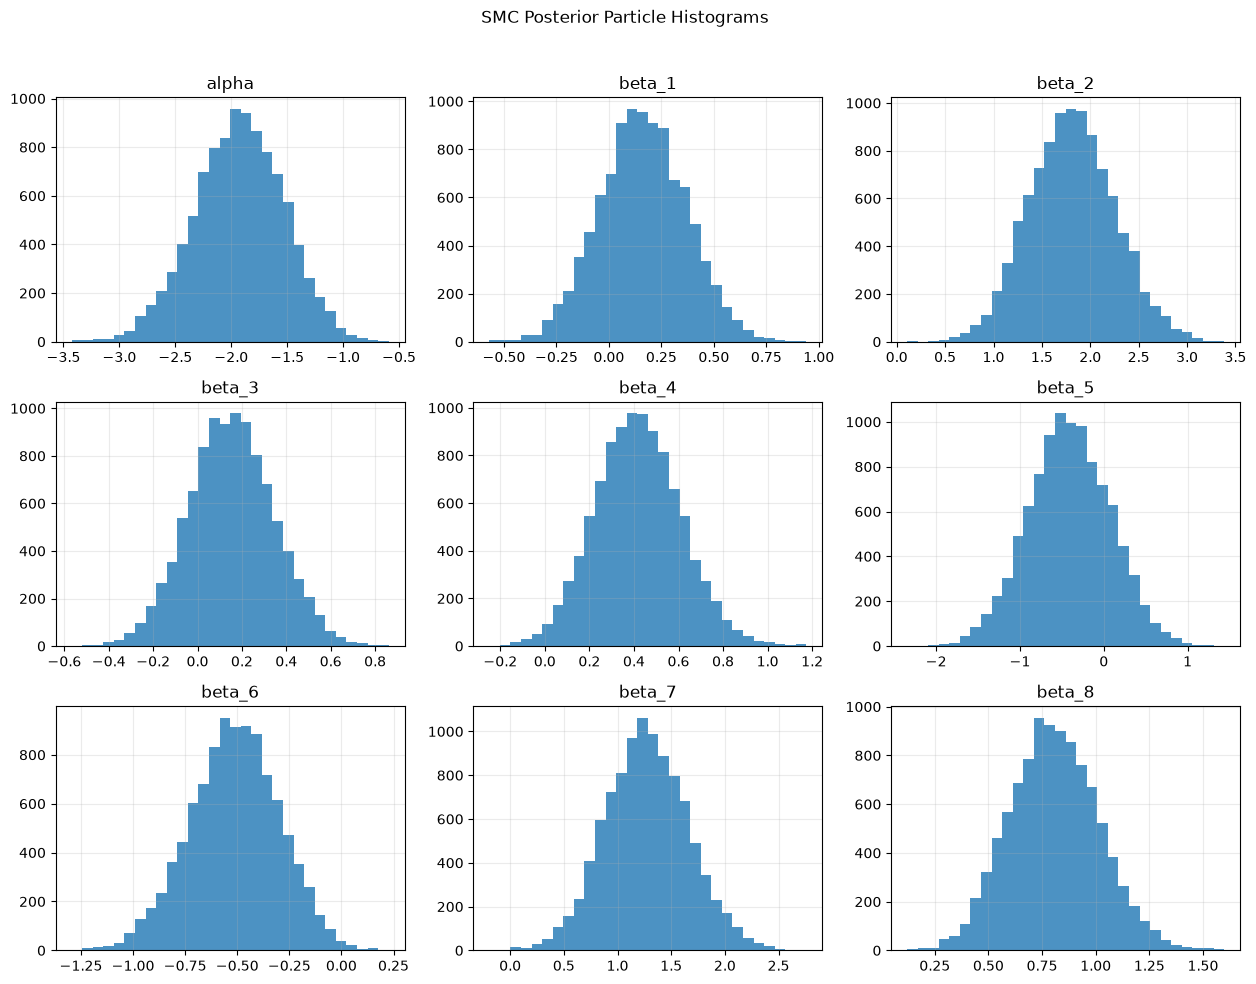

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt


def plot_smc_histograms(particles, bins=30, figsize_per_panel=(4.2, 3.2)):
    """Plot histograms for alpha and each beta from final SMC particles."""
    n_params = particles.shape[1]  # alpha + betas
    n_cols = min(3, n_params)
    n_rows = math.ceil(n_params / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
    )
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

    labels = ["alpha"] + [f"beta_{j+1}" for j in range(n_params - 1)]

    for idx in range(n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        if idx < n_params:
            ax.hist(particles[:, idx], bins=bins, alpha=0.8)
            ax.set_title(labels[idx])
            ax.grid(alpha=0.25)
        else:
            ax.axis("off")

    fig.suptitle("SMC Posterior Particle Histograms", y=1.02)
    plt.tight_layout()
    plt.show()


# Usage
plot_smc_histograms(train_smc["particles"])

Now, it is time to report some stats information for the posterior distributions of alpha and betas 

In [15]:
import numpy as np
import pandas as pd

def report_posterior_means_and_ci(particles, predictor_names=None, ci_level=0.95):
    """
    Report posterior means and equal-tailed credible intervals for alpha and betas.

    Parameters
    ----------
    smc_obj : SMC
        Fitted SMC object with current particles.
    predictor_names : list[str] | None
        Names for betas. If None, try `chosen_X.columns`, else beta_1, beta_2, ...
    ci_level : float
        Credible interval level (default 0.95).

    Returns
    -------
    pandas.DataFrame
        Columns: parameter, mean, ci_low, ci_high, width, excludes_zero
    """
    n_params = particles.shape[1]
    n_betas = n_params - 1

    if predictor_names is None:
        try:
            predictor_names = list(chosen_X.columns)
        except NameError:
            predictor_names = [f"beta_{j+1}" for j in range(n_betas)]

    if len(predictor_names) != n_betas:
        raise ValueError(
            f"Expected {n_betas} predictor names, got {len(predictor_names)}"
        )

    labels = ["alpha"] + [
        f"beta_{j+1} ({name})" for j, name in enumerate(predictor_names)
    ]

    alpha = (1.0 - ci_level) / 2.0
    means = particles.mean(axis=0)
    ci_low = np.quantile(particles, alpha, axis=0)
    ci_high = np.quantile(particles, 1.0 - alpha, axis=0)
    widths = ci_high - ci_low

    df = pd.DataFrame(
        {
            "parameter": labels,
            "mean": means,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "width": widths
        }
    )

    print(f"Posterior means and {int(ci_level * 100)}% credible intervals")
    print(f"n_particles = {particles.shape[0]}")
    return df


# Usage
posterior_summary_df = report_posterior_means_and_ci(train_smc["particles"])
posterior_summary_df

Posterior means and 95% credible intervals
n_particles = 10000


,parameter,mean,ci_low,ci_high,width
0,alpha,-1.930099,-2.739939,-1.171926,1.568013
1,beta_1 (age),0.162388,-0.237672,0.568442,0.806114
2,beta_2 (sex),1.813616,0.982030,2.697967,1.715937
3,beta_3 (rest-bp),0.152818,-0.218911,0.534503,0.753415
4,beta_4 (serum-chol),0.418384,0.054848,0.803583,0.748735
5,beta_5 (fasting-blood-sugar),-0.412175,-1.377650,0.525803,1.903453
6,beta_6 (max-heart-rate),-0.512876,-0.945751,-0.108478,0.837273
7,beta_7 (angina),1.273211,0.510639,2.055981,1.545342
8,beta_8 (oldpeak),0.806626,0.419565,1.226366,0.806801


### Stage 2: Evidence-based Variable Selection

- Use the same 8 predictors from Stage 1.
- Enumerate all `2^8 = 256` subsets via bitmask (`mask = 0` is intercept-only).
- For each model `M`, reuse Stage 1 helpers:
  - estimate train evidence `log p_M(y_train)` by SMC
  - compute posterior predictive probabilities on the **same** held-out test set
- Rank models by estimated log evidence and compare test predictive performance.


In [16]:
from tqdm import trange
import pandas as pd
import numpy as np


PREDICTOR_NAMES = list(X_columns)
N_PREDICTORS = len(PREDICTOR_NAMES)
N_MODELS = 1 << N_PREDICTORS  # 256

# Reuse Stage 1 80/20 split for a fair comparison across models
X_train, X_test, y_train, y_test = split_train_test(X_jax, y_jax, train_frac=0.8, seed=0)

# Reduce particles if 256 SMC runs are too slow; increase for a final report
STAGE2_PARTICLES = 5_000
STAGE2_BASE_SEED = 42


def mask_to_set_indexes(mask: int):
    return [bit for bit in range(N_PREDICTORS) if (mask & (1 << bit)) > 0]


def mask_to_variable_names(mask: int):
    idx = mask_to_set_indexes(mask)
    return [PREDICTOR_NAMES[j] for j in idx]


def run_one_model(mask: int, no_samples: int, seed: int):
    idx = mask_to_set_indexes(mask)
    names = mask_to_variable_names(mask)
    Xtr = X_train[:, idx] if idx else X_train[:, :0]
    Xte = X_test[:, idx] if idx else X_test[:, :0]

    smc_out = run_smc_on_data(Xtr, y_train, no_samples=no_samples, seed=seed)
    test_metrics = eval_posterior_predictive(smc_out["particles"], Xte, y_test)

    return {
        "mask": mask,
        "variables": ", ".join(names) if names else "(intercept only)",
        "n_predictors": len(idx),
        "dimension": 1 + len(idx),
        "log_evidence": smc_out["log_evidence"],
        "n_lambda_steps": len(smc_out["lambda_path"]),
        "test_accuracy": test_metrics["accuracy"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_brier": test_metrics["brier"],
        "test_log_loss": test_metrics["log_loss"],
        "test_log_score": test_metrics["log_score"],
    }


stage2_rows = []
for mask in trange(N_MODELS, desc="Stage 2: 256 models"):
    stage2_rows.append(
        run_one_model(
            mask,
            no_samples=STAGE2_PARTICLES,
            seed=STAGE2_BASE_SEED + mask,
        )
    )

stage2_df = pd.DataFrame(stage2_rows)
stage2_df = stage2_df.sort_values("log_evidence", ascending=False).reset_index(drop=True)
stage2_df["rank"] = np.arange(1, len(stage2_df) + 1)
best_log_z = stage2_df.loc[0, "log_evidence"]
stage2_df["evidence_gap"] = best_log_z - stage2_df["log_evidence"]

print("Top 20 models by train log evidence")
display_cols = [
    "rank",
    "mask",
    "variables",
    "dimension",
    "log_evidence",
    "evidence_gap",
    "test_accuracy",
    "test_roc_auc",
    "test_brier",
    "test_log_loss",
]
print(stage2_df[display_cols].head(20).to_string(index=False, float_format=lambda x: f"{x: .4f}"))

best = stage2_df.iloc[0]
full = stage2_df.loc[stage2_df["mask"] == (N_MODELS - 1)].iloc[0]
print("\nBest model by log evidence")
print(f"  rank=1 | mask={int(best['mask'])} | dim={int(best['dimension'])}")
print(f"  variables: {best['variables']}")
print(f"  log p_M(y_train)={best['log_evidence']:.4f}")
print(f"  test accuracy={best['test_accuracy']:.4f}, ROC-AUC={best['test_roc_auc']:.4f}, Brier={best['test_brier']:.4f}")

print("\nFull 8-predictor model")
print(f"  rank={int(full['rank'])} | mask={int(full['mask'])}")
print(f"  log p_M(y_train)={full['log_evidence']:.4f} | gap vs best={full['evidence_gap']:.4f}")
print(f"  test accuracy={full['test_accuracy']:.4f}, ROC-AUC={full['test_roc_auc']:.4f}, Brier={full['test_brier']:.4f}")

stage2_df[display_cols]


Stage 2: 256 models: 100%|█| 256/

Top 20 models by train log evidence
 rank  mask                                                                      variables  dimension  log_evidence  evidence_gap  test_accuracy  test_roc_auc  test_brier  test_log_loss
    1   234                               sex, serum-chol, max-heart-rate, angina, oldpeak          6     -113.0376        0.0000         0.8148        0.8681      0.1522         0.4626
    2   250          sex, serum-chol, fasting-blood-sugar, max-heart-rate, angina, oldpeak          7     -113.6285        0.5909         0.7963        0.8694      0.1525         0.4634
    3   235                          age, sex, serum-chol, max-heart-rate, angina, oldpeak          7     -114.1763        1.1387         0.7963        0.8667      0.1523         0.4602
    4   226                                           sex, max-heart-rate, angina, oldpeak          5     -114.3398        1.3023         0.7778        0.8639      0.1547         0.4765
    5   202                       

,rank,mask,variables,dimension,log_evidence,evidence_gap,test_accuracy,test_roc_auc,test_brier,test_log_loss
0,1,234,"sex, serum-chol, max-heart-rate, angina, oldpeak",6,-113.037552,0.000000,0.814815,0.868056,0.152199,0.462587
1,2,250,"sex, serum-chol, fasting-blood-sugar, max-hear...",7,-113.628494,0.590942,0.796296,0.869444,0.152517,0.463420
2,3,235,"age, sex, serum-chol, max-heart-rate, angina, ...",7,-114.176292,1.138741,0.796296,0.866667,0.152314,0.460200
3,4,226,"sex, max-heart-rate, angina, oldpeak",5,-114.339821,1.302269,0.777778,0.863889,0.154658,0.476478
4,5,202,"sex, serum-chol, angina, oldpeak",5,-114.992661,1.955109,0.759259,0.816667,0.177262,0.534711
...,...,...,...,...,...,...,...,...,...,...
251,252,20,"rest-bp, fasting-blood-sugar",3,-152.302170,39.264618,0.611111,0.543750,0.241123,0.674975
252,253,16,fasting-blood-sugar,2,-152.813644,39.776093,0.555556,0.466667,0.247044,0.687226
253,254,24,"serum-chol, fasting-blood-sugar",3,-153.005692,39.968140,0.537037,0.556944,0.249515,0.692825
254,255,29,"age, rest-bp, serum-chol, fasting-blood-sugar",5,-153.175156,40.137604,0.648148,0.662500,0.229735,0.651361


### Stage 2 Report: Rank Models by Evidence and Compare Test Performance

After running the bitmask experiment, inspect:

- `stage2_df`: all 256 models ranked by `log_evidence`
- `evidence_gap`: `log p_{M*}(y_train) - log p_M(y_train)`
- held-out metrics: accuracy, ROC-AUC, Brier, log loss / log score

Paper selection rule (uniform model prior):

$$
\hat{M} = \arg\max_M \log p_M(y_{\mathrm{train}})
$$

Then compare that model against the full 8-predictor model on the test set.


Stage 2 comparison table (all 256 models, ranked by log evidence)


,rank,mask,variables,n_predictors,dimension,log_evidence,evidence_gap,test_accuracy,test_roc_auc,test_brier,test_log_loss,test_log_score
0,1,234,"sex, serum-chol, max-heart-rate, angina, oldpeak",5,6,-113.037552,0.000000,0.814815,0.868056,0.152199,0.462587,-24.979675
1,2,250,"sex, serum-chol, fasting-blood-sugar, max-hear...",6,7,-113.628494,0.590942,0.796296,0.869444,0.152517,0.463420,-25.024660
2,3,235,"age, sex, serum-chol, max-heart-rate, angina, ...",6,7,-114.176292,1.138741,0.796296,0.866667,0.152314,0.460200,-24.850819
3,4,226,"sex, max-heart-rate, angina, oldpeak",4,5,-114.339821,1.302269,0.777778,0.863889,0.154658,0.476478,-25.729828
4,5,202,"sex, serum-chol, angina, oldpeak",4,5,-114.992661,1.955109,0.759259,0.816667,0.177262,0.534711,-28.874416
5,6,242,"sex, fasting-blood-sugar, max-heart-rate, angi...",5,6,-115.216202,2.178650,0.777778,0.866667,0.155994,0.481270,-25.988562
6,7,227,"age, sex, max-heart-rate, angina, oldpeak",5,6,-115.233704,2.196152,0.777778,0.866667,0.155905,0.474338,-25.614273
7,8,251,"age, sex, serum-chol, fasting-blood-sugar, max...",7,8,-115.383919,2.346367,0.759259,0.863889,0.154173,0.465531,-25.138687
8,9,230,"sex, rest-bp, max-heart-rate, angina, oldpeak",5,6,-115.395775,2.358223,0.777778,0.870833,0.149657,0.462054,-24.950891
9,10,195,"age, sex, angina, oldpeak",4,5,-115.416870,2.379318,0.777778,0.827778,0.172104,0.516846,-27.909678



Top 10 models
 rank  mask                                                                  variables  n_predictors  dimension  log_evidence  evidence_gap  test_accuracy  test_roc_auc  test_brier  test_log_loss  test_log_score
    1   234                           sex, serum-chol, max-heart-rate, angina, oldpeak             5          6     -113.0376        0.0000         0.8148        0.8681      0.1522         0.4626        -24.9797
    2   250      sex, serum-chol, fasting-blood-sugar, max-heart-rate, angina, oldpeak             6          7     -113.6285        0.5909         0.7963        0.8694      0.1525         0.4634        -25.0247
    3   235                      age, sex, serum-chol, max-heart-rate, angina, oldpeak             6          7     -114.1763        1.1387         0.7963        0.8667      0.1523         0.4602        -24.8508
    4   226                                       sex, max-heart-rate, angina, oldpeak             4          5     -114.3398        1.30

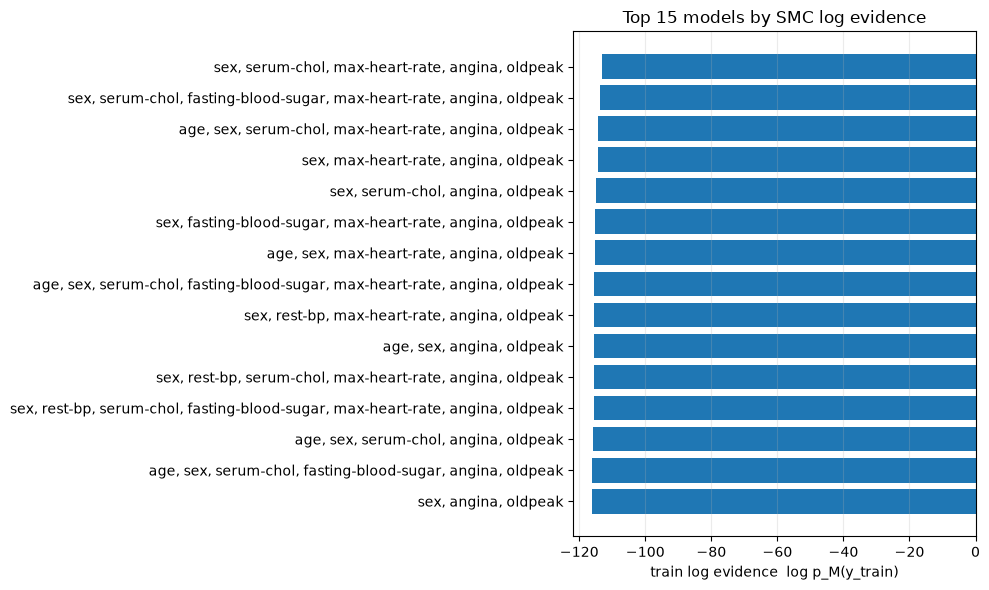

,selection,mask,variables,log_evidence,test_accuracy,test_roc_auc,test_brier
0,best log evidence,234,"sex, serum-chol, max-heart-rate, angina, oldpeak",-113.037552,0.814815,0.868056,0.152199
1,best test ROC-AUC,254,"sex, rest-bp, serum-chol, fasting-blood-sugar,...",-115.580338,0.796296,0.879167,0.147987
2,best test accuracy,234,"sex, serum-chol, max-heart-rate, angina, oldpeak",-113.037552,0.814815,0.868056,0.152199
3,full 8-predictor model,255,"age, sex, rest-bp, serum-chol, fasting-blood-s...",-117.373344,0.777778,0.868056,0.148782


In [17]:
import matplotlib.pyplot as plt

report_cols = [
    "rank",
    "mask",
    "variables",
    "n_predictors",
    "dimension",
    "log_evidence",
    "evidence_gap",
    "test_accuracy",
    "test_roc_auc",
    "test_brier",
    "test_log_loss",
    "test_log_score",
]

print("Stage 2 comparison table (all 256 models, ranked by log evidence)")
stage2_report = stage2_df[report_cols].copy()
display(stage2_report.head(30))

# compact top-10 markdown-style table
print("\nTop 10 models")
print(
    stage2_report.head(10).to_string(
        index=False,
        float_format=lambda x: f"{x: .4f}",
    )
)

# highlight: best evidence vs best test AUC vs full model
best_ev = stage2_df.iloc[0]
best_auc = stage2_df.sort_values("test_roc_auc", ascending=False).iloc[0]
best_acc = stage2_df.sort_values("test_accuracy", ascending=False).iloc[0]
full = stage2_df.loc[stage2_df["mask"] == (N_MODELS - 1)].iloc[0]

summary = pd.DataFrame(
    [
        {
            "selection": "best log evidence",
            "mask": int(best_ev["mask"]),
            "variables": best_ev["variables"],
            "log_evidence": best_ev["log_evidence"],
            "test_accuracy": best_ev["test_accuracy"],
            "test_roc_auc": best_ev["test_roc_auc"],
            "test_brier": best_ev["test_brier"],
        },
        {
            "selection": "best test ROC-AUC",
            "mask": int(best_auc["mask"]),
            "variables": best_auc["variables"],
            "log_evidence": best_auc["log_evidence"],
            "test_accuracy": best_auc["test_accuracy"],
            "test_roc_auc": best_auc["test_roc_auc"],
            "test_brier": best_auc["test_brier"],
        },
        {
            "selection": "best test accuracy",
            "mask": int(best_acc["mask"]),
            "variables": best_acc["variables"],
            "log_evidence": best_acc["log_evidence"],
            "test_accuracy": best_acc["test_accuracy"],
            "test_roc_auc": best_acc["test_roc_auc"],
            "test_brier": best_acc["test_brier"],
        },
        {
            "selection": "full 8-predictor model",
            "mask": int(full["mask"]),
            "variables": full["variables"],
            "log_evidence": full["log_evidence"],
            "test_accuracy": full["test_accuracy"],
            "test_roc_auc": full["test_roc_auc"],
            "test_brier": full["test_brier"],
        },
    ]
)

print("\nSelected-model comparison")
print(summary.to_string(index=False, float_format=lambda x: f"{x: .4f}"))

top_k = stage2_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_k["variables"][::-1], top_k["log_evidence"][::-1])
ax.set_xlabel("train log evidence  log p_M(y_train)")
ax.set_title("Top 15 models by SMC log evidence")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

summary


### Stage 3: Larger Model Space

- Introduce a model prior $p(M)$
- Search by maximizing $S(M) = \log p(M) + \log p_M(y) + \mathbb{E}[\log p(\theta\mid M)]$
- Strategies share one interface: `find(X, y) -> SearchResult`
- `SearchResult` returns the selected subset together with posterior `alpha` and `betas`
- Compare selected model with Lasso logistic regression and BIC
- Study prior sensitivity

This is useful when enumerating all $2^p$ models is no longer feasible.


In [18]:
from libs.search import (
    GreedyForwardSearch,
    IndependentInclusionPrior,
    SearchResult,
)

# Greedy forward: intercept-only -> add one variable until S(M) stops improving
# S(M) = log p(M) + log p_M(y) + E[log p(alpha, betas | M)]
greedy = GreedyForwardSearch(
    model_prior=IndependentInclusionPrior(rho=0.5),
    n_particles=5_000,
    seed=42,
    verbose=True,
)

greedy_result = greedy.find(
    X_train,
    y_train,
    predictor_names=list(X_columns),
)

print("\nSelected model")
print(f"  mask={greedy_result.mask}")
print(f"  variables={greedy_result.variables}")
print(f"  log p_M(y)={greedy_result.log_evidence:.4f}")
print(f"  log p(M)  ={greedy_result.log_model_prior:.4f}")
print(f"  log p(theta)={greedy_result.log_param_prior:.4f}")
print(f"  S(M)      ={greedy_result.score:.4f}")
print(f"  alpha     ={greedy_result.alpha:.4f}")
print(f"  betas     ={greedy_result.betas}")
greedy_result


[greedy] start intercept-only | log p_M(y)=-151.4396 | log p(theta)=-2.0214 | S=-159.0062
  try add age                  | log p_M(y)=-149.3031 | log p(theta)=-3.3928 | S=-158.2411
  try add sex                  | log p_M(y)=-142.5015 | log p(theta)=-3.9186 | S=-151.9652
  try add rest-bp              | log p_M(y)=-151.1827 | log p(theta)=-3.3729 | S=-160.1008
  try add serum-chol           | log p_M(y)=-151.6892 | log p(theta)=-3.3689 | S=-160.6033
  try add fasting-blood-sugar  | log p_M(y)=-152.8136 | log p(theta)=-3.3806 | S=-161.7394
  try add max-heart-rate       | log p_M(y)=-137.3338 | log p(theta)=-3.5217 | S=-146.4006
  try add angina               | log p_M(y)=-132.7896 | log p(theta)=-4.2242 | S=-142.5590
  try add oldpeak              | log p_M(y)=-132.9984 | log p(theta)=-3.6011 | S=-142.1447
[greedy] accept oldpeak | vars=['oldpeak'] | S=-142.1447
  try add age                  | log p_M(y)=-133.3373 | log p(theta)=-4.9327 | S=-143.8151
  try add sex                  | l

SearchResult(mask=226, variables=['sex', 'max-heart-rate', 'angina', 'oldpeak'], alpha=-1.6775342226028442, betas=array([ 1.4041799 , -0.51872367,  1.3037608 ,  0.831386  ], dtype=float32), log_evidence=-114.3398208618164, log_model_prior=-5.545177444479562, log_param_prior=-8.590747833251953, score=-128.47574613954794, included_indices=[1, 5, 6, 7], particles=array([[-2.2598338 ,  1.6414634 , -0.2542121 ,  2.0210154 ,  0.69670165],
       [-1.9698713 ,  1.4625895 , -0.6828355 ,  1.6662165 ,  0.9131869 ],
       [-1.4282924 ,  1.4090645 , -0.38748926,  1.5099517 ,  1.1542037 ],
       ...,
       [-1.7174978 ,  1.4919051 , -0.5052155 ,  1.0250124 ,  1.0148106 ],
       [-2.30579   ,  1.8534452 , -0.6436174 ,  1.0622039 ,  0.8591315 ],
       [-1.1280955 ,  1.3082838 , -0.77530825,  0.6126369 ,  0.54543567]],
      shape=(5000, 5), dtype=float32), history=[{'step': 0, 'added': None, 'mask': 0, 'variables': [], 'log_evidence': -151.4396209716797, 'log_param_prior': -2.021409511566162, 's

In [19]:
from libs.search import ForwardBackwardSearch, IndependentInclusionPrior

# Forward-backward: from intercept-only, each step tries add-one AND remove-one.
# Move to the neighbour with largest S(M); stop when none improves.
fwd_bwd = ForwardBackwardSearch(
    model_prior=IndependentInclusionPrior(rho=0.5),
    n_particles=5_000,
    seed=42,
    verbose=True,
)

fwd_bwd_result = fwd_bwd.find(
    X_train,
    y_train,
    predictor_names=list(X_columns),
)

print("\nSelected model")
print(f"  mask={fwd_bwd_result.mask}")
print(f"  variables={fwd_bwd_result.variables}")
print(f"  log p_M(y)={fwd_bwd_result.log_evidence:.4f}")
print(f"  log p(M)  ={fwd_bwd_result.log_model_prior:.4f}")
print(f"  log p(theta)={fwd_bwd_result.log_param_prior:.4f}")
print(f"  S(M)      ={fwd_bwd_result.score:.4f}")
print(f"  alpha     ={fwd_bwd_result.alpha:.4f}")
print(f"  betas     ={fwd_bwd_result.betas}")
fwd_bwd_result


[fwd-bwd] start intercept-only | log p_M(y)=-151.4396 | log p(theta)=-2.0214 | S=-159.0062
  try add    age                  | log p_M(y)=-149.3031 | log p(theta)=-3.3928 | S=-158.2411
  try add    sex                  | log p_M(y)=-142.5015 | log p(theta)=-3.9186 | S=-151.9652
  try add    rest-bp              | log p_M(y)=-151.1827 | log p(theta)=-3.3729 | S=-160.1008
  try add    serum-chol           | log p_M(y)=-151.6892 | log p(theta)=-3.3689 | S=-160.6033
  try add    fasting-blood-sugar  | log p_M(y)=-152.8136 | log p(theta)=-3.3806 | S=-161.7394
  try add    max-heart-rate       | log p_M(y)=-137.3338 | log p(theta)=-3.5217 | S=-146.4006
  try add    angina               | log p_M(y)=-132.7896 | log p(theta)=-4.2242 | S=-142.5590
  try add    oldpeak              | log p_M(y)=-132.9984 | log p(theta)=-3.6011 | S=-142.1447
[fwd-bwd] add oldpeak | vars=['oldpeak'] | S=-142.1447
  try add    age                  | log p_M(y)=-133.3373 | log p(theta)=-4.9327 | S=-143.8151
  try ad

SearchResult(mask=226, variables=['sex', 'max-heart-rate', 'angina', 'oldpeak'], alpha=-1.6775342226028442, betas=array([ 1.4041799 , -0.51872367,  1.3037608 ,  0.831386  ], dtype=float32), log_evidence=-114.3398208618164, log_model_prior=-5.545177444479562, log_param_prior=-8.590747833251953, score=-128.47574613954794, included_indices=[1, 5, 6, 7], particles=array([[-2.2598338 ,  1.6414634 , -0.2542121 ,  2.0210154 ,  0.69670165],
       [-1.9698713 ,  1.4625895 , -0.6828355 ,  1.6662165 ,  0.9131869 ],
       [-1.4282924 ,  1.4090645 , -0.38748926,  1.5099517 ,  1.1542037 ],
       ...,
       [-1.7174978 ,  1.4919051 , -0.5052155 ,  1.0250124 ,  1.0148106 ],
       [-2.30579   ,  1.8534452 , -0.6436174 ,  1.0622039 ,  0.8591315 ],
       [-1.1280955 ,  1.3082838 , -0.77530825,  0.6126369 ,  0.54543567]],
      shape=(5000, 5), dtype=float32), history=[{'step': 0, 'action': None, 'variable': None, 'mask': 0, 'variables': [], 'log_evidence': -151.4396209716797, 'log_param_prior': -2.

In [20]:
from libs.search import StochasticSearch, IndependentInclusionPrior

# Stochastic MH search on model space:
#   - proposal: add or delete a random variable with probability 0.5 each
#   - accept with a = min(1, exp(S'-S) * q(M|M') / q(M'|M))
#   - return the highest-scoring visited model
stochastic = StochasticSearch(
    model_prior=IndependentInclusionPrior(rho=0.5),
    n_particles=5_000,
    seed=42,
    n_steps=40,
    p_add=0.5,
    p_delete=0.5,
    verbose=True,
)

stochastic_result = stochastic.find(
    X_train,
    y_train,
    predictor_names=list(X_columns),
)

print("\nSelected model (best visited under MH)")
print(f"  mask={stochastic_result.mask}")
print(f"  variables={stochastic_result.variables}")
print(f"  log p_M(y)={stochastic_result.log_evidence:.4f}")
print(f"  log p(M)  ={stochastic_result.log_model_prior:.4f}")
print(f"  log p(theta)={stochastic_result.log_param_prior:.4f}")
print(f"  S(M)      ={stochastic_result.score:.4f}")
print(f"  alpha     ={stochastic_result.alpha:.4f}")
print(f"  betas     ={stochastic_result.betas}")
stochastic_result


[mh] start intercept-only | log p_M(y)=-151.4396 | log p(theta)=-2.0214 | S=-159.0062
[mh] n_steps=40, p_add=0.5, p_delete=0.5
  step   1: try add    age                  | S'=-158.2411 | a=1.000 | ACCEPT
  step   2: try delete age                  | S'=-159.0062 | a=0.116 | reject
  step   3: try add    angina               | S'=-143.3138 | a=1.000 | ACCEPT
  step   4: try delete angina               | S'=-158.2411 | a=0.000 | reject
  step   5: try add    max-heart-rate       | S'=-141.6020 | a=1.000 | ACCEPT
  step   6: try delete angina               | S'=-149.1050 | a=0.000 | reject
  step   7: try add    fasting-blood-sugar  | S'=-144.2846 | a=0.085 | reject
  step   8: try delete angina               | S'=-149.1050 | a=0.000 | reject
  step   9: try delete age                  | S'=-138.8395 | a=1.000 | ACCEPT
  step  10: try add    age                  | S'=-141.6020 | a=0.126 | reject
  step  11: try delete angina               | S'=-146.4006 | a=0.000 | reject
  step  12: try

SearchResult(mask=226, variables=['sex', 'max-heart-rate', 'angina', 'oldpeak'], alpha=-1.6775342226028442, betas=array([ 1.4041799 , -0.51872367,  1.3037608 ,  0.831386  ], dtype=float32), log_evidence=-114.3398208618164, log_model_prior=-5.545177444479562, log_param_prior=-8.590747833251953, score=-128.47574613954794, included_indices=[1, 5, 6, 7], particles=array([[-2.2598338 ,  1.6414634 , -0.2542121 ,  2.0210154 ,  0.69670165],
       [-1.9698713 ,  1.4625895 , -0.6828355 ,  1.6662165 ,  0.9131869 ],
       [-1.4282924 ,  1.4090645 , -0.38748926,  1.5099517 ,  1.1542037 ],
       ...,
       [-1.7174978 ,  1.4919051 , -0.5052155 ,  1.0250124 ,  1.0148106 ],
       [-2.30579   ,  1.8534452 , -0.6436174 ,  1.0622039 ,  0.8591315 ],
       [-1.1280955 ,  1.3082838 , -0.77530825,  0.6126369 ,  0.54543567]],
      shape=(5000, 5), dtype=float32), history=[{'step': 0, 'action': None, 'variable': None, 'accepted': True, 'mask': 0, 'variables': [], 'log_evidence': -151.4396209716797, 'log

### Stage 3 baseline: Lasso logistic regression (keep top 4)

Fit L1-penalized logistic regression on the training set and keep the 4 predictors with the largest \(|\beta_j|\). This is the paper's screening-style classical baseline.


In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

LASSO_TOP_K = 4
predictor_names = list(X_columns)

# Cross-validated L1 logistic on TRAIN
lasso_cv = LogisticRegressionCV(
    penalty="l1",
    solver="liblinear",
    Cs=20,
    cv=5,
    scoring="neg_log_loss",
    max_iter=2000,
    random_state=0,
)
lasso_cv.fit(np.asarray(X_train), np.asarray(y_train))

lasso_coef = np.ravel(lasso_cv.coef_)
lasso_intercept = float(np.ravel(lasso_cv.intercept_)[0])

lasso_rank_df = pd.DataFrame(
    {
        "variable": predictor_names,
        "lasso_coef": lasso_coef,
        "abs_coef": np.abs(lasso_coef),
    }
).sort_values("abs_coef", ascending=False).reset_index(drop=True)
lasso_rank_df["rank"] = np.arange(1, len(lasso_rank_df) + 1)

lasso_top4_df = lasso_rank_df.head(LASSO_TOP_K).copy()
lasso_top4_names = lasso_top4_df["variable"].tolist()
lasso_top4_indices = [predictor_names.index(name) for name in lasso_top4_names]
lasso_mask = int(sum(1 << j for j in lasso_top4_indices))

print(f"CV-chosen C = {float(lasso_cv.C_[0]):.4g}")
print(f"Lasso intercept = {lasso_intercept:.4f}")
print("\nAll Lasso coefficients (ranked by |beta|)")
print(lasso_rank_df.to_string(index=False, float_format=lambda x: f"{x: .4f}"))

print(f"\nTop {LASSO_TOP_K} variables kept:")
print(lasso_top4_df[["rank", "variable", "lasso_coef"]].to_string(index=False, float_format=lambda x: f"{x: .4f}"))
print(f"lasso_mask = {lasso_mask} | indices = {lasso_top4_indices}")

# Refit unpenalized logistic on the top-4 subset (train), then score test
Xtr4 = np.asarray(X_train)[:, lasso_top4_indices]
Xte4 = np.asarray(X_test)[:, lasso_top4_indices]
logit4 = LogisticRegression(penalty=None, solver="lbfgs", max_iter=2000)
logit4.fit(Xtr4, np.asarray(y_train))
p_hat = logit4.predict_proba(Xte4)[:, 1]
y_hat = (p_hat >= 0.5).astype(int)
y_te = np.asarray(y_test)

print("\nUnpenalized logistic on Lasso top-4, test performance")
print(f"  accuracy : {accuracy_score(y_te, y_hat):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_te, p_hat):.4f}")
print(f"  Brier    : {brier_score_loss(y_te, p_hat):.4f}")
print(f"  log loss : {log_loss(y_te, np.clip(p_hat, 1e-15, 1 - 1e-15)):.4f}")

lasso_top4_df


CV-chosen C = 1.624
Lasso intercept = -1.8163

All Lasso coefficients (ranked by |beta|)
           variable  lasso_coef  abs_coef  rank
                sex      1.6951    1.6951     1
             angina      1.1665    1.1665     2
            oldpeak      0.7477    0.7477     3
     max-heart-rate     -0.4888    0.4888     4
         serum-chol      0.3800    0.3800     5
fasting-blood-sugar     -0.2494    0.2494     6
                age      0.1432    0.1432     7
            rest-bp      0.1276    0.1276     8

Top 4 variables kept:
 rank       variable  lasso_coef
    1            sex      1.6951
    2         angina      1.1665
    3        oldpeak      0.7477
    4 max-heart-rate     -0.4888
lasso_mask = 226 | indices = [1, 6, 7, 5]

Unpenalized logistic on Lasso top-4, test performance
  accuracy : 0.7778
  ROC-AUC  : 0.8625
  Brier    : 0.1553
  log loss : 0.4788


/Users/andytran/Works/Research/NTU/MiniProject-PhD-/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/andytran/Works/Research/NTU/MiniProject-PhD-/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/Users/andytran/Works/Research/NTU/MiniProject-PhD-/.venv

,variable,lasso_coef,abs_coef,rank
0,sex,1.695090,1.695090,1
1,angina,1.166499,1.166499,2
2,oldpeak,0.747681,0.747681,3
3,max-heart-rate,-0.488756,0.488756,4


### Enumerate all subsets of the Lasso top-4

Paper Sec 9.5: after screening, enumerate all \(2^{4}=16\) models on the reduced set and select \(\hat M=\arg\max_M S(M)\).


In [22]:
import pandas as pd
from libs.search import RestrictedEnumerationSearch, IndependentInclusionPrior

lasso_enum = RestrictedEnumerationSearch(
    allowed_indices=lasso_top4_indices,
    model_prior=IndependentInclusionPrior(rho=0.5),
    n_particles=5_000,
    seed=42,
    verbose=True,
)

lasso_enum_result = lasso_enum.find(
    X_train,
    y_train,
    predictor_names=list(X_columns),
)

lasso_enum_df = pd.DataFrame(lasso_enum_result.history)
print("\nAll 16 Lasso-screened models ranked by S(M)")
print(
    lasso_enum_df[
        ["variables", "n_predictors", "log_evidence", "log_model_prior", "log_param_prior", "score"]
    ].to_string(index=False, float_format=lambda x: f"{x: .4f}")
)

print("\nBest subset among Lasso top-4")
print(f"  mask={lasso_enum_result.mask}")
print(f"  variables={lasso_enum_result.variables}")
print(f"  log p_M(y)={lasso_enum_result.log_evidence:.4f}")
print(f"  log p(M)  ={lasso_enum_result.log_model_prior:.4f}")
print(f"  log p(theta)={lasso_enum_result.log_param_prior:.4f}")
print(f"  S(M)      ={lasso_enum_result.score:.4f}")
print(f"  alpha     ={lasso_enum_result.alpha:.4f}")
print(f"  betas     ={lasso_enum_result.betas}")
lasso_enum_result


[enum] enumerating 16 subsets of ['sex', 'angina', 'oldpeak', 'max-heart-rate']
  M=(intercept only)                         | log p_M(y)=-151.4396 | log p(theta)=-2.0214 | S=-159.0062
  M=sex                                      | log p_M(y)=-142.5015 | log p(theta)=-3.9186 | S=-151.9652
  M=angina                                   | log p_M(y)=-132.7896 | log p(theta)=-4.2242 | S=-142.5590
  M=sex, angina                              | log p_M(y)=-127.2264 | log p(theta)=-6.0253 | S=-138.7970
  M=oldpeak                                  | log p_M(y)=-132.9984 | log p(theta)=-3.6011 | S=-142.1447
  M=sex, oldpeak                             | log p_M(y)=-124.9314 | log p(theta)=-5.5841 | S=-136.0606
  M=angina, oldpeak                          | log p_M(y)=-121.3480 | log p(theta)=-5.5684 | S=-132.4616
  M=sex, angina, oldpeak                     | log p_M(y)=-116.0356 | log p(theta)=-7.3627 | S=-128.9436
  M=max-heart-rate                           | log p_M(y)=-137.3338 | log p(thet

SearchResult(mask=226, variables=['sex', 'max-heart-rate', 'angina', 'oldpeak'], alpha=-1.6775342226028442, betas=array([ 1.4041799 , -0.51872367,  1.3037608 ,  0.831386  ], dtype=float32), log_evidence=-114.3398208618164, log_model_prior=-5.545177444479562, log_param_prior=-8.590747833251953, score=-128.47574613954794, included_indices=[1, 5, 6, 7], particles=array([[-2.2598338 ,  1.6414634 , -0.2542121 ,  2.0210154 ,  0.69670165],
       [-1.9698713 ,  1.4625895 , -0.6828355 ,  1.6662165 ,  0.9131869 ],
       [-1.4282924 ,  1.4090645 , -0.38748926,  1.5099517 ,  1.1542037 ],
       ...,
       [-1.7174978 ,  1.4919051 , -0.5052155 ,  1.0250124 ,  1.0148106 ],
       [-2.30579   ,  1.8534452 , -0.6436174 ,  1.0622039 ,  0.8591315 ],
       [-1.1280955 ,  1.3082838 , -0.77530825,  0.6126369 ,  0.54543567]],
      shape=(5000, 5), dtype=float32), history=[{'submask': 15, 'mask': 226, 'variables': ['sex', 'max-heart-rate', 'angina', 'oldpeak'], 'n_predictors': 4, 'log_evidence': -114.33

### Stage 3 Report: Compare Lasso vs Greedy vs Forward–Backward

Compare selected variable sets and **held-out test** predictive performance on the same 80/20 split.

| Method | How model is chosen | Test evaluation |
|---|---|---|
| Lasso CV | L1 logistic on all 8 predictors | Lasso predicted probabilities |
| Lasso top-4 | 4 largest \(\|\beta_j\|\), then unpenalized logistic | unpenalized logistic |
| Lasso enum | all \(2^4\) subsets of top-4, max \(S(M)\) | SMC posterior predictive |
| Greedy forward | add-one until \(S(M)\) stops improving | SMC posterior predictive |
| Forward–backward | add/remove neighbours until \(S(M)\) stops | SMC posterior predictive |
| Stochastic MH | MH add/delete with \(p=0.5\) each; best visited | SMC posterior predictive |


In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, log_loss


def _classical_test_metrics(clf, X_te, y_te):
    p_hat = clf.predict_proba(np.asarray(X_te))[:, 1]
    y_hat = (p_hat >= 0.5).astype(int)
    y_te = np.ravel(np.asarray(y_te))
    return {
        "test_accuracy": float(accuracy_score(y_te, y_hat)),
        "test_roc_auc": float(roc_auc_score(y_te, p_hat)),
        "test_brier": float(brier_score_loss(y_te, p_hat)),
        "test_log_loss": float(log_loss(y_te, np.clip(p_hat, 1e-15, 1 - 1e-15))),
    }


def _search_test_metrics(result):
    idx = result.included_indices
    X_te = np.asarray(X_test)[:, idx] if idx else np.asarray(X_test)[:, :0]
    m = eval_posterior_predictive(result.particles, X_te, y_test)
    return {
        "test_accuracy": m["accuracy"],
        "test_roc_auc": m["roc_auc"],
        "test_brier": m["brier"],
        "test_log_loss": m["log_loss"],
    }


def _row(method, mask, variables, n_predictors, score, log_evidence, metrics, notes=""):
    return {
        "method": method,
        "mask": mask,
        "variables": ", ".join(variables) if variables else "(intercept only)",
        "n_predictors": int(n_predictors),
        "S(M)": score,
        "log_evidence": log_evidence,
        **metrics,
        "notes": notes,
    }


search_results = {
    "Lasso enum (best S(M))": lasso_enum_result,
    "Greedy forward": greedy_result,
    "Forward-backward": fwd_bwd_result,
    "Stochastic MH": stochastic_result,
}

unique_masks = {r.mask for r in search_results.values()}
if len(unique_masks) == 1:
    only_mask = next(iter(unique_masks))
    only_vars = next(iter(search_results.values())).variables
    print(
        "Note: all Bayesian search methods selected the same model "
        f"(mask={only_mask}, vars={only_vars}). "
        "Identical S(M), log_evidence, and test metrics are therefore expected."
    )
else:
    print(f"Note: search methods selected {len(unique_masks)} distinct models (masks={sorted(unique_masks)})")

rows = []

# 1) Lasso top-4 + unpenalized logistic
Xtr4 = np.asarray(X_train)[:, lasso_top4_indices]
Xte4 = np.asarray(X_test)[:, lasso_top4_indices]
logit4 = LogisticRegression(penalty=None, solver="lbfgs", max_iter=2000)
logit4.fit(Xtr4, np.ravel(np.asarray(y_train)))
rows.append(
    _row(
        "Lasso top-4 (unpenalized)",
        mask=lasso_mask,
        variables=lasso_top4_names,
        n_predictors=4,
        score=np.nan,
        log_evidence=np.nan,
        metrics=_classical_test_metrics(logit4, Xte4, y_test),
        notes="screen by |beta|, then MLE logistic",
    )
)

# 2) Best S(M) among 16 Lasso-screened subsets
rows.append(
    _row(
        "Lasso enum (best S(M))",
        mask=lasso_enum_result.mask,
        variables=lasso_enum_result.variables,
        n_predictors=lasso_enum_result.n_predictors,
        score=lasso_enum_result.score,
        log_evidence=lasso_enum_result.log_evidence,
        metrics=_search_test_metrics(lasso_enum_result),
        notes="enumerate 2^4 subsets of Lasso top-4",
    )
)

# 3) Greedy forward
rows.append(
    _row(
        "Greedy forward",
        mask=greedy_result.mask,
        variables=greedy_result.variables,
        n_predictors=greedy_result.n_predictors,
        score=greedy_result.score,
        log_evidence=greedy_result.log_evidence,
        metrics=_search_test_metrics(greedy_result),
        notes="add-one until S(M) stalls",
    )
)

# 4) Forward-backward
rows.append(
    _row(
        "Forward-backward",
        mask=fwd_bwd_result.mask,
        variables=fwd_bwd_result.variables,
        n_predictors=fwd_bwd_result.n_predictors,
        score=fwd_bwd_result.score,
        log_evidence=fwd_bwd_result.log_evidence,
        metrics=_search_test_metrics(fwd_bwd_result),
        notes="add/remove neighbours until S(M) stalls",
    )
)

# 5) Stochastic MH search
rows.append(
    _row(
        "Stochastic MH",
        mask=stochastic_result.mask,
        variables=stochastic_result.variables,
        n_predictors=stochastic_result.n_predictors,
        score=stochastic_result.score,
        log_evidence=stochastic_result.log_evidence,
        metrics=_search_test_metrics(stochastic_result),
        notes="MH add/delete p=0.5; return best visited",
    )
)

stage3_compare_df = pd.DataFrame(rows)
display_cols = [
    "method",
    "mask",
    "variables",
    "n_predictors",
    "S(M)",
    "log_evidence",
    "test_accuracy",
    "test_roc_auc",
    "test_brier",
    "test_log_loss",
    "notes",
]
print("Stage 3 comparison (same train/test split)")
print(
    stage3_compare_df[display_cols].to_string(
        index=False,
        float_format=lambda x: f"{x: .4f}" if pd.notna(x) else "   n/a",
    )
)

# highlight winners on each numeric column
num_cols = ["S(M)", "log_evidence", "test_accuracy", "test_roc_auc"]
print("\nBest method by column")
for col in num_cols:
    sub = stage3_compare_df.dropna(subset=[col])
    if len(sub) == 0:
        continue
    if col in ("test_brier", "test_log_loss"):
        i = sub[col].idxmin()
    else:
        i = sub[col].idxmax()
    print(f"  {col:<16} -> {sub.loc[i, 'method']}  ({sub.loc[i, col]:.4f})")

print("\nLower is better: test_brier, test_log_loss")
for col in ["test_brier", "test_log_loss"]:
    i = stage3_compare_df[col].idxmin()
    print(f"  {col:<16} -> {stage3_compare_df.loc[i, 'method']}  ({stage3_compare_df.loc[i, col]:.4f})")

stage3_compare_df


Note: all Bayesian search methods selected the same model (mask=226, vars=['sex', 'max-heart-rate', 'angina', 'oldpeak']). Identical S(M), log_evidence, and test metrics are therefore expected.


/Users/andytran/Works/Research/NTU/MiniProject-PhD-/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Stage 3 comparison (same train/test split)
                   method  mask                            variables  n_predictors      S(M)  log_evidence  test_accuracy  test_roc_auc  test_brier  test_log_loss                                    notes
Lasso top-4 (unpenalized)   226 sex, angina, oldpeak, max-heart-rate             4       NaN           NaN         0.7778        0.8625      0.1553         0.4788      screen by |beta|, then MLE logistic
   Lasso enum (best S(M))   226 sex, max-heart-rate, angina, oldpeak             4 -128.4757     -114.3398         0.7778        0.8639      0.1547         0.4765     enumerate 2^4 subsets of Lasso top-4
           Greedy forward   226 sex, max-heart-rate, angina, oldpeak             4 -128.4757     -114.3398         0.7778        0.8639      0.1547         0.4765                add-one until S(M) stalls
         Forward-backward   226 sex, max-heart-rate, angina, oldpeak             4 -128.4757     -114.3398         0.7778        0.8639      

,method,mask,variables,n_predictors,S(M),log_evidence,test_accuracy,test_roc_auc,test_brier,test_log_loss,notes
0,Lasso top-4 (unpenalized),226,"sex, angina, oldpeak, max-heart-rate",4,NaN,NaN,0.777778,0.862500,0.155327,0.478777,"screen by |beta|, then MLE logistic"
1,Lasso enum (best S(M)),226,"sex, max-heart-rate, angina, oldpeak",4,-128.475746,-114.339821,0.777778,0.863889,0.154658,0.476478,enumerate 2^4 subsets of Lasso top-4
2,Greedy forward,226,"sex, max-heart-rate, angina, oldpeak",4,-128.475746,-114.339821,0.777778,0.863889,0.154658,0.476478,add-one until S(M) stalls
3,Forward-backward,226,"sex, max-heart-rate, angina, oldpeak",4,-128.475746,-114.339821,0.777778,0.863889,0.154658,0.476478,add/remove neighbours until S(M) stalls
4,Stochastic MH,226,"sex, max-heart-rate, angina, oldpeak",4,-128.475746,-114.339821,0.777778,0.863889,0.154658,0.476478,MH add/delete p=0.5; return best visited


### Prior sensitivity on the full model space (Stage 3)

We vary the **parameter prior** $p(\alpha, \beta \mid M)$ while keeping the model prior $p(M)$ fixed (`rho=0.5`). For each prior specification we run **greedy forward search** over all $2^8$ subsets and record whether the selected model changes.

Score used throughout:
$$S(M) = \log p(M) + \log p_M(y) + \mathbb{E}[\log p(\alpha, \beta \mid M)]$$

where SMC is run with the same parameter prior that enters $S(M)$.

In [24]:
import pandas as pd
from libs.param_prior import GaussianParamPrior, LaplaceBetaPrior, DEFAULT_PARAM_PRIOR
from libs.search import GreedyForwardSearch, ForwardBackwardSearch, IndependentInclusionPrior

PRIOR_SENS_PARTICLES = 5_000
PRIOR_SENS_SEED = 42

# Parameter priors to compare (baseline matches Stage 1 / paper setup)
PARAM_PRIOR_SPECS = [
    DEFAULT_PARAM_PRIOR,
    GaussianParamPrior(alpha_scale=1.5, beta_scale=0.75, label="tight"),
    GaussianParamPrior(alpha_scale=5.0, beta_scale=2.5, label="loose"),
    GaussianParamPrior(alpha_scale=3.0, beta_scale=0.5, label="strong_shrink"),
    GaussianParamPrior(alpha_scale=3.0, beta_scale=5.0, label="weak_slopes"),
    LaplaceBetaPrior(alpha_scale=3.0, beta_scale=1.5, label="laplace_betas"),
]

SEARCH_STRATEGIES = {
    "greedy": GreedyForwardSearch,
    "forward_backward": ForwardBackwardSearch,
}
ACTIVE_SEARCH = "greedy"  # change to "forward_backward" to compare stepwise add/remove


def _search_test_metrics_from_result(result):
    idx = result.included_indices
    X_te = np.asarray(X_test)[:, idx] if idx else np.asarray(X_test)[:, :0]
    m = eval_posterior_predictive(result.particles, X_te, y_test)
    return m


prior_sensitivity_rows = []
prior_sensitivity_results = {}

SearchCls = SEARCH_STRATEGIES[ACTIVE_SEARCH]
for param_prior in PARAM_PRIOR_SPECS:
    print(f"\n=== {ACTIVE_SEARCH} | param prior: {param_prior.name} ===")
    searcher = SearchCls(
        model_prior=IndependentInclusionPrior(rho=0.5),
        param_prior=param_prior,
        n_particles=PRIOR_SENS_PARTICLES,
        seed=PRIOR_SENS_SEED,
        verbose=True,
    )
    result = searcher.find(
        X_train,
        y_train,
        predictor_names=list(X_columns),
    )
    key = (ACTIVE_SEARCH, param_prior.name)
    prior_sensitivity_results[key] = result

    test_m = _search_test_metrics_from_result(result)
    prior_sensitivity_rows.append(
        {
            "search": ACTIVE_SEARCH,
            "param_prior": param_prior.name,
            "mask": result.mask,
            "variables": ", ".join(result.variables) if result.variables else "(intercept only)",
            "n_predictors": result.n_predictors,
            "S(M)": result.score,
            "log_evidence": result.log_evidence,
            "log_param_prior": result.log_param_prior,
            "test_accuracy": test_m["accuracy"],
            "test_roc_auc": test_m["roc_auc"],
            "test_brier": test_m["brier"],
            "test_log_loss": test_m["log_loss"],
        }
    )

prior_sensitivity_df = pd.DataFrame(prior_sensitivity_rows)
print("\nPrior sensitivity summary")
print(
    prior_sensitivity_df.to_string(
        index=False,
        float_format=lambda x: f"{x: .4f}",
    )
)

unique_masks = prior_sensitivity_df["mask"].nunique()
print(
    f"\nSelected {unique_masks} distinct model(s) across {len(PARAM_PRIOR_SPECS)} priors."
)
if unique_masks == 1:
    print("All priors picked the same subset (mask=", int(prior_sensitivity_df['mask'].iloc[0]), ").")
else:
    print("Masks found:", sorted(prior_sensitivity_df["mask"].unique().tolist()))

prior_sensitivity_df


=== greedy | param prior: baseline ===
[greedy] start intercept-only | log p_M(y)=-151.4396 | log p(theta)=-2.0214 | S=-159.0062
  try add age                  | log p_M(y)=-149.3031 | log p(theta)=-3.3928 | S=-158.2411
  try add sex                  | log p_M(y)=-142.5015 | log p(theta)=-3.9186 | S=-151.9652
  try add rest-bp              | log p_M(y)=-151.1827 | log p(theta)=-3.3729 | S=-160.1008
  try add serum-chol           | log p_M(y)=-151.6892 | log p(theta)=-3.3689 | S=-160.6033
  try add fasting-blood-sugar  | log p_M(y)=-152.8136 | log p(theta)=-3.3806 | S=-161.7394
  try add max-heart-rate       | log p_M(y)=-137.3338 | log p(theta)=-3.5217 | S=-146.4006
  try add angina               | log p_M(y)=-132.7896 | log p(theta)=-4.2242 | S=-142.5590
  try add oldpeak              | log p_M(y)=-132.9984 | log p(theta)=-3.6011 | S=-142.1447
[greedy] accept oldpeak | vars=['oldpeak'] | S=-142.1447
  try add age                  | log p_M(y)=-133.3373 | log p(theta)=-4.9327 | S=-143

,search,param_prior,mask,variables,n_predictors,S(M),log_evidence,log_param_prior,test_accuracy,test_roc_auc,test_brier,test_log_loss
0,greedy,baseline,226,"sex, max-heart-rate, angina, oldpeak",4,-128.475746,-114.339821,-8.590748,0.777778,0.863889,0.154658,0.476478
1,greedy,tight,234,"sex, serum-chol, max-heart-rate, angina, oldpeak",5,-127.205463,-112.772797,-8.887489,0.796296,0.870833,0.149745,0.457809
2,greedy,loose,194,"sex, angina, oldpeak",3,-131.270614,-117.137115,-8.588321,0.703704,0.806250,0.178966,0.545196
3,greedy,strong_shrink,234,"sex, serum-chol, max-heart-rate, angina, oldpeak",5,-130.406362,-115.380035,-9.481149,0.796296,0.872222,0.150148,0.460557
4,greedy,weak_slopes,194,"sex, angina, oldpeak",3,-133.577772,-118.109978,-9.922617,0.703704,0.806250,0.178785,0.545150
5,greedy,laplace_betas,226,"sex, max-heart-rate, angina, oldpeak",4,-129.658322,-114.875427,-9.237718,0.777778,0.863889,0.154976,0.477297


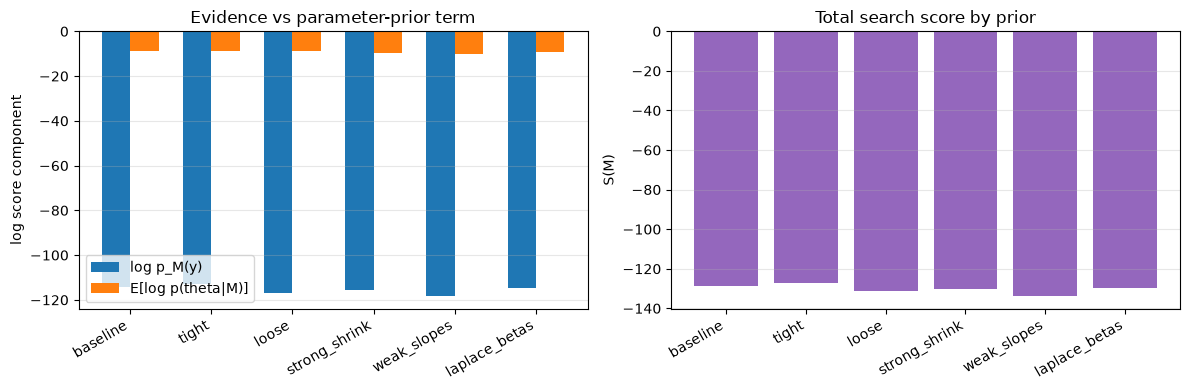

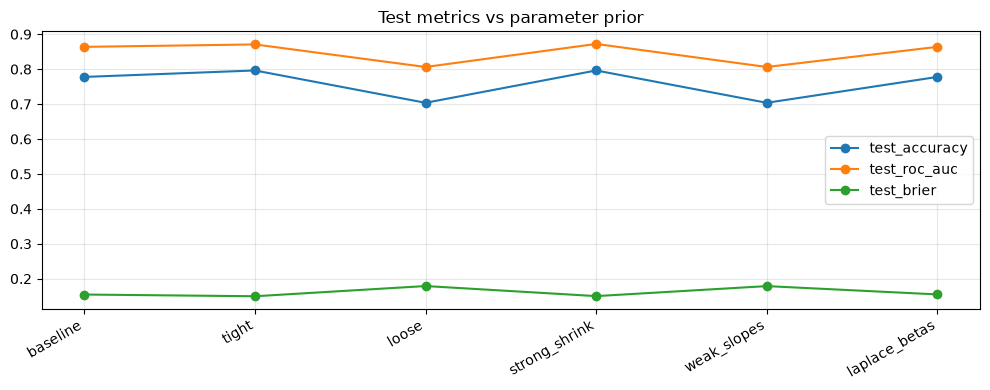

SMC model evaluations per prior:
  baseline       -> 5 models scored
  tight          -> 6 models scored
  loose          -> 4 models scored
  strong_shrink  -> 6 models scored
  weak_slopes    -> 4 models scored
  laplace_betas  -> 5 models scored


In [25]:
import matplotlib.pyplot as plt

# Compare S(M) components across priors for the selected model of each run
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = prior_sensitivity_df.copy()
x = np.arange(len(plot_df))
width = 0.35

axes[0].bar(x - width / 2, plot_df["log_evidence"], width, label="log p_M(y)")
axes[0].bar(x + width / 2, plot_df["log_param_prior"], width, label="E[log p(theta|M)]")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df["param_prior"], rotation=30, ha="right")
axes[0].set_ylabel("log score component")
axes[0].set_title("Evidence vs parameter-prior term")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x, plot_df["S(M)"], color="tab:purple")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["param_prior"], rotation=30, ha="right")
axes[1].set_ylabel("S(M)")
axes[1].set_title("Total search score by prior")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Held-out test metrics (should be compared only after models are selected)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(plot_df))
for metric, color in [
    ("test_accuracy", "tab:blue"),
    ("test_roc_auc", "tab:green"),
    ("test_brier", "tab:orange"),
]:
    ax.plot(x, plot_df[metric], marker="o", label=metric)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["param_prior"], rotation=30, ha="right")
ax.set_title("Test metrics vs parameter prior")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Optional: overlay greedy paths (number of SMC evaluations) from history
if prior_sensitivity_results:
    print("SMC model evaluations per prior:")
    for (_, prior_name), result in prior_sensitivity_results.items():
        n_evals = len(result.history)
        print(f"  {prior_name:<14} -> {n_evals} models scored")

### Comments on prior-sensitivity results (heart data)

Greedy forward search over the full $2^8$ model space produced **three distinct selected models** across the six parameter priors:

| Group | Priors | Selected variables (mask) | $S(M)$ | Test acc / AUC |
|-------|--------|---------------------------|--------|----------------|
| A | baseline, laplace_betas | sex, max-heart-rate, angina, oldpeak (**226**) | $\approx -128.5$ / $-129.7$ | 0.778 / 0.864 |
| B | tight, strong_shrink | sex, serum-chol, max-heart-rate, angina, oldpeak (**234**, 5 predictors) | $\approx -127.2$ / $-130.4$ | **0.796 / 0.871** |
| C | loose, weak_slopes | sex, angina, oldpeak (**194**, 3 predictors) | $\approx -131.3$ / $-133.6$ | 0.704 / 0.806 |

**Left plot (evidence vs parameter-prior term).** Tighter / strongly shrinking priors (groups B) push down $\mathbb{E}[\log p(\theta \mid M)]$ (more negative blue/orange bars on the right) but can still yield higher $\log p_M(y)$ because the posterior concentrates on smaller coefficients. Looser priors on slopes (group C) keep the parameter-prior penalty smaller yet select sparser, worse-fitting subsets.

**Right plot (total $S(M)$).** The tight prior achieves the **best search score** ($S \approx -127.2$) by adding `serum-chol` to the baseline 4-variable set. This does **not** match the baseline prior's selected model, showing that the parameter prior materially affects model choice when it enters $S(M)$.

**Test-metric plot.** Held-out performance is best for the **5-variable models** chosen under tight / strong-shrink priors (higher accuracy and AUC, lower Brier / log-loss), while loose / weak-slope priors under-select variables and perform worst on test. Baseline and Laplace-on-slopes priors agree on the 4-variable model with intermediate test performance.

**Takeaway.** For this dataset the baseline prior is **moderately robust** (same subset as Laplace slopes), but tightening $\beta$ priors shifts selection toward a richer model with slightly better predictive performance, whereas very flat slope priors favour overly sparse models. Any reported "best model" should therefore state which parameter prior was used.